# Practical Statistics for Data Scientists
# AI-Assisted Statistics for Data Scientists
# Chapter 5: Classification
> (c) 2019-2026 Peter C. Bruce, Andrew Bruce, Peter Gedeck

In [1]:
# from statsmodels.genmod.generalized_linear_model import GLMResults
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, KBinsDiscretizer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import mlba
import numpy as np
import pandas as pd
import pygam
import random
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

random.seed(123)

# Location of the data files. Adjust this path if you keep the data
# files in a different directory.
from pathlib import Path
DATA_DIR = Path('../../data')


## Classification
### Naive Bayes
#### The Naive Solution

In [1]:
loan_data = pd.read_csv(DATA_DIR / "loan_data.csv.gz")

predictors = ["purpose_", "home_", "emp_len_"]
outcome = "outcome"
X = pd.get_dummies(loan_data[predictors], prefix="", prefix_sep="", dtype=int)
y = loan_data[outcome]

naive_model = MultinomialNB(alpha=0.01, fit_prior=True)
naive_model.fit(X, y)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.01
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [1]:
new_loan = X.loc[146:146, :]

In [1]:
print("predicted class: ", naive_model.predict(new_loan)[0])

probabilities = pd.DataFrame(naive_model.predict_proba(new_loan),
                             columns=naive_model.classes_)
print("predicted probabilities", probabilities)

predicted class:  default
predicted probabilities     default  paid off
0  0.653696  0.346304


#### Numeric Predictor Variables

In [1]:
num_cols = ["borrower_score", "payment_inc_ratio"]
cat_cols = ["purpose_", "home_", "emp_len_"]
mixed_naive_model = Pipeline([
    ("pre", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", KBinsDiscretizer(n_bins=5, strategy="uniform"), num_cols),
    ])),
    ("clf", MultinomialNB()),
])
X = loan_data[cat_cols + num_cols]
mixed_naive_model.fit(X, loan_data["outcome"])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

### Discriminant Analysis
#### A Simple Example

In [1]:
loan3000 = pd.read_csv(DATA_DIR / "loan3000.csv")

loan3000.outcome = loan3000.outcome.astype("category")

predictors = ["borrower_score", "payment_inc_ratio"]
outcome = "outcome"

X = loan3000[predictors]
y = loan3000[outcome]

loan_lda = LinearDiscriminantAnalysis()
loan_lda.fit(X, y)
pd.DataFrame(loan_lda.scalings_, index=X.columns)

,0
borrower_score,7.175839
payment_inc_ratio,-0.099676


In [1]:
pred = pd.DataFrame(loan_lda.predict_proba(loan3000[predictors]),
                    columns=loan_lda.classes_)
pred.head()

,default,paid off
0,0.553544,0.446456
1,0.558953,0.441047
2,0.272696,0.727304
3,0.506254,0.493746
4,0.609952,0.390048


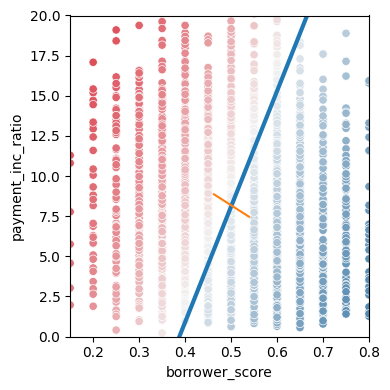

In [1]:
# Use scalings and center of means to determine decision boundary
center = np.mean(loan_lda.means_, axis=0)
slope = - loan_lda.scalings_[0] / loan_lda.scalings_[1]
intercept = center[1] - center[0] * slope

# payment_inc_ratio for borrower_score of 0 and 20
x_0 = (0 - intercept) / slope
x_20 = (20 - intercept) / slope

lda_df = pd.concat([loan3000, pred["default"]], axis=1)
lda_df.head()

fig, ax = plt.subplots(figsize=(4, 4))
g = sns.scatterplot(x="borrower_score", y="payment_inc_ratio",
                    hue="default", data=lda_df,
                    palette=sns.diverging_palette(240, 10, n=9, as_cmap=True),
                    ax=ax, legend=False)

ax.set_ylim(0, 20)
ax.set_xlim(0.15, 0.8)
ax.plot((x_0, x_20), (0, 20), linewidth=3)
ax.plot(*loan_lda.means_.transpose())

plt.tight_layout()
plt.show()

### Logistic Regression
#### Logistic Regression and the GLM

In [1]:
predictors = ["payment_inc_ratio", "purpose_", "home_", "emp_len_",
              "borrower_score"]
outcome = "outcome"
X = pd.get_dummies(loan_data[predictors], prefix="", prefix_sep="",
                   drop_first=True, dtype=int)
y = loan_data[outcome]

logit_reg = LogisticRegression(C=np.inf, max_iter=1000)
logit_reg.fit(X, y)

/Users/petergedeck/cdd/practical-statistics-for-data-scientists-code-3e/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",inf
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [1]:
print("intercept ", logit_reg.intercept_[0])
print("classes", logit_reg.classes_)
pd.DataFrame({"coeff": logit_reg.coef_[0]}, index=X.columns)

intercept  -1.6261242575653818
classes ['default' 'paid off']


,coeff
payment_inc_ratio,-0.079885
borrower_score,4.610744
debt_consolidation,-0.250128
home_improvement,-0.411826
major_purchase,-0.228901
medical,-0.528521
other,-0.620839
small_business,-1.222285
OWN,-0.052460
RENT,-0.159205


#### Predicted Values from Logistic Regression

In [1]:
pred = pd.DataFrame(logit_reg.predict_log_proba(X),
                    columns=logit_reg.classes_)
pred.describe()

,default,paid off
count,45342.000000,45342.000000
mean,-0.758078,-0.760365
std,0.378317,0.390689
min,-2.771842,-3.546430
25%,-0.986107,-0.977608
50%,-0.697477,-0.688836
75%,-0.471941,-0.466850
max,-0.029251,-0.064588


In [1]:
pred = pd.DataFrame(logit_reg.predict_proba(X),
                    columns=logit_reg.classes_)
pred.describe()

,default,paid off
count,45342.000000,45342.000000
mean,0.499934,0.500066
std,0.167427,0.167427
min,0.062547,0.028827
25%,0.373026,0.376210
50%,0.497840,0.502160
75%,0.623790,0.626974
max,0.971173,0.937453


#### Assessing the Model

In [1]:
y_numbers = [1 if yi == "default" else 0 for yi in y]
logit_reg_sm = sm.GLM(y_numbers, X.assign(const=1),
                      family=sm.families.Binomial())
logit_result = logit_reg_sm.fit()
print(logit_result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                45342
Model:                            GLM   Df Residuals:                    45330
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -28757.
Date:                Sun, 31 May 2026   Deviance:                       57515.
Time:                        18:07:11   Pearson chi2:                 4.54e+04
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1112
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
payment_inc_ratio      0.0797      0

In [1]:
formula = ("outcome ~ bs(payment_inc_ratio, df=4) + purpose_ + "
           "home_ + emp_len_ + bs(borrower_score, df=4)")
model = smf.glm(formula=formula, data=loan_data, family=sm.families.Binomial())
results = model.fit()

In [1]:
print(results.summary())

                             Generalized Linear Model Regression Results                             
Dep. Variable:     ['outcome[default]', 'outcome[paid off]']   No. Observations:                45342
Model:                                                   GLM   Df Residuals:                    45324
Model Family:                                       Binomial   Df Model:                           17
Link Function:                                         Logit   Scale:                          1.0000
Method:                                                 IRLS   Log-Likelihood:                -28744.
Date:                                       Sun, 31 May 2026   Deviance:                       57487.
Time:                                               18:07:11   Pearson chi2:                 4.54e+04
No. Iterations:                                            5   Pseudo R-squ. (CS):             0.1117
Covariance Type:                                   nonrobust                      

##### Analysis of residuals

### Evaluating Classification Models
####  Confusion Matrix

In [1]:
pred = logit_reg.predict(X)
pred_y = logit_reg.predict(X) == "default"
true_y = y == "default"
true_pos = true_y & pred_y
true_neg = ~true_y & ~pred_y
false_pos = ~true_y & pred_y
false_neg = true_y & ~pred_y

conf_mat = pd.DataFrame([[np.sum(true_pos), np.sum(false_neg)],
                         [np.sum(false_pos), np.sum(true_neg)]],
                       index=["Y = default", "Y = paid off"],
                       columns=["Yhat = default", "Yhat = paid off"])
conf_mat

,Yhat = default,Yhat = paid off
Y = default,14321,8350
Y = paid off,8140,14531


In [1]:
print(confusion_matrix(y_true=y, y_pred=logit_reg.predict(X)))

[[14321  8350]
 [ 8140 14531]]


In [1]:
mlba.classificationSummary(y_true=y, y_pred=logit_reg.predict(X))

Confusion Matrix (Accuracy 0.6363)

         Prediction
  Actual  default paid off
 default    14321     8350
paid off     8140    14531


#### Precision, Recall, and Specificity

In [1]:
y_pred = logit_reg.predict(X)
print("precision ", precision_score(y, y_pred, pos_label="default"))
print("recall.    ", recall_score(y, y_pred, pos_label="default"))
print("specificity", recall_score(y, y_pred, pos_label="paid off"))

precision  0.6375940519122034
recall.     0.6316880596356579


specificity 0.640950994662785


#### ROC Curve

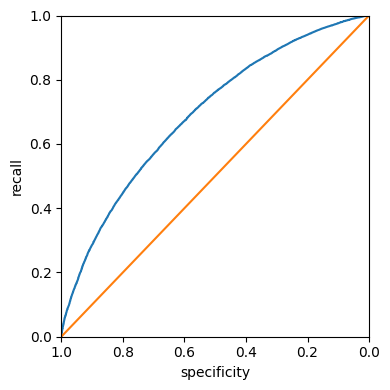

In [1]:
fpr, tpr, thresholds = roc_curve(y, logit_reg.predict_proba(X)[:, 0],
                                 pos_label="default")
roc_df = pd.DataFrame({"recall": tpr, "specificity": 1 - fpr})

ax = roc_df.plot(x="specificity", y="recall", figsize=(4, 4), legend=False)
ax.set_ylim(0, 1)
ax.set_xlim(1, 0)
ax.plot((1, 0), (0, 1))
ax.set_xlabel("specificity")
ax.set_ylabel("recall")

plt.tight_layout()
plt.show()

#### AUC

In [1]:
print(np.sum(roc_df.recall[:-1] * np.diff(1 - roc_df.specificity)))
print(roc_auc_score([1 if yi == "default" else 0 for yi in y],
                    logit_reg.predict_proba(X)[:, 0]))

0.6917057288869074
0.6917058067118191


### Strategies for Imbalanced Data
#### Undersampling

In [1]:
full_train_set = pd.read_csv(DATA_DIR / "full_train_set.csv.gz")

print("percentage of loans in default: ",
      100 * np.mean(full_train_set.outcome == "default"))

percentage of loans in default:  18.894546909248504


In [1]:
predictors = ["payment_inc_ratio", "purpose_", "home_", "emp_len_",
              "dti", "revol_bal", "revol_util"]
outcome = "outcome"
X = pd.get_dummies(full_train_set[predictors], prefix="", prefix_sep="",
                   drop_first=True, dtype=int)
y = full_train_set[outcome]

full_model = LogisticRegression(C=np.inf, max_iter=10_000)
full_model.fit(X, y)
print("percentage of loans predicted to default: ",
      100 * np.mean(full_model.predict(X) == "default"))

/Users/petergedeck/cdd/practical-statistics-for-data-scientists-code-3e/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


percentage of loans predicted to default:  0.3883754073357947


#### Oversampling and Up/Down Weighting

In [1]:
default_wt = 1 / np.mean(full_train_set.outcome == "default")
wt = [default_wt if outcome == "default" else 1
      for outcome in full_train_set.outcome]

full_model = LogisticRegression(C=np.inf, max_iter=10_000)
full_model.fit(X, y, sample_weight=wt)
print("percentage of loans predicted to default (weighting): ",
      100 * np.mean(full_model.predict(X) == "default"))

/Users/petergedeck/cdd/practical-statistics-for-data-scientists-code-3e/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


percentage of loans predicted to default (weighting):  57.61874203038663


# Supplementary Material
## Figure 5-2. Graph of the logit function that maps a probability to a scale suitable for a linear model

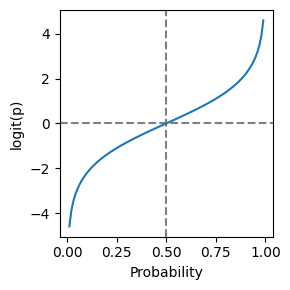

In [1]:
p = np.arange(0.01, 1, 0.01)
df = pd.DataFrame({
    "p": p,
    "logit": np.log(p / (1 - p)),
    "odds": p / (1 - p),
})

fig, ax = plt.subplots(figsize=(3, 3))
ax.axhline(0, color="grey", linestyle="--")
ax.axvline(0.5, color="grey", linestyle="--")
ax.plot(df["p"], df["logit"])
ax.set_xlabel("Probability")
ax.set_ylabel("logit(p)")

plt.tight_layout()
plt.show()

## How to control the order of the classes in Python

In [1]:
# If you have a feature or outcome variable that is ordinal, use
# the scikit-learn `OrdinalEncoder` to replace the categories
# (here, "paid off" and "default") with numbers. In the below code,
# we replace "paid off" with 0 and "default" with 1. This reverses
# the order of the predicted classes and as a consequence, the
# coefficients will be reversed. You will however now need to
# keep track of how the the numbers map back to the classes.

In [1]:
predictors = ["payment_inc_ratio", "purpose_", "home_", "emp_len_",
              "borrower_score"]
outcome = "outcome"
X = pd.get_dummies(loan_data[predictors], prefix="", prefix_sep="",
                   drop_first=True, dtype=int)
enc = OrdinalEncoder(categories=[["paid off", "default"]])
y_enc = enc.fit_transform(loan_data[[outcome]]).ravel()

logit_reg_enc = LogisticRegression(C=np.inf, max_iter=1000)
logit_reg_enc.fit(X, y_enc)

print("intercept ", logit_reg_enc.intercept_[0])
print("classes", logit_reg_enc.classes_)
pd.DataFrame({"coeff": logit_reg_enc.coef_[0]}, index=X.columns)

intercept  1.6262802328204813
classes [0. 1.]


/Users/petergedeck/cdd/practical-statistics-for-data-scientists-code-3e/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


,coeff
payment_inc_ratio,0.079896
borrower_score,-4.611003
debt_consolidation,0.250206
home_improvement,0.411879
major_purchase,0.228987
medical,0.528678
other,0.620869
small_business,1.222274
OWN,0.052453
RENT,0.159220


## Figure 5-3. The relationship between the odds ratio and the log-odds ratio

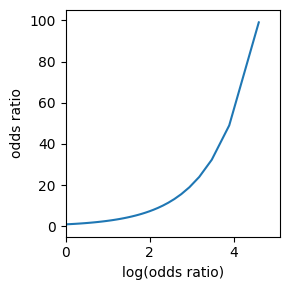

In [1]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.plot(df["logit"], df["odds"])
ax.set_xlabel("log(odds ratio)")
ax.set_ylabel("odds ratio")
ax.set_xlim(0, 5.1)
ax.set_ylim(-5, 105)

plt.tight_layout()
plt.show()

## Figure 5-4. Partial residuals from logistic regression

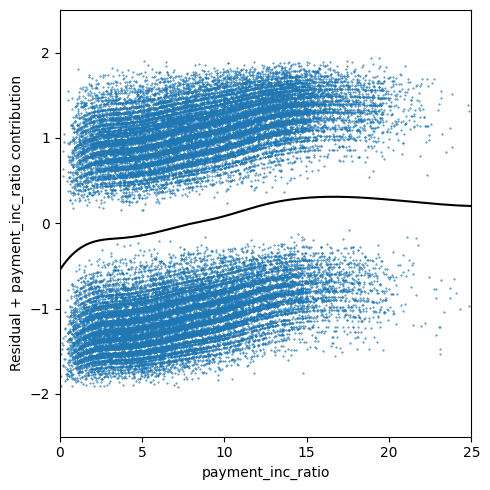

In [1]:
def partial_residual_plot(model, df, outcome, feature, fig, ax):
    y_actual = [0 if s == "default" else 1 for s in df[outcome]]
    y_pred = model.predict(df)
    org_params = model.params.copy()
    zero_params = model.params.copy()
    # set model parametes of other features to 0
    for i, name in enumerate(zero_params.index):
        if feature in name:
            continue
        zero_params.iloc[i] = 0.0
    model.initialize(model.model, zero_params)
    feature_prediction = model.predict(df)
    ypartial = -np.log(1 / feature_prediction - 1)
    ypartial -= np.mean(ypartial)
    model.initialize(model.model, org_params)
    results = pd.DataFrame({
        "feature": df[feature],
        "residual": -2 * (y_actual - y_pred),
        "ypartial": ypartial / 2,
    })
    results = results.sort_values(by=["feature"])

    ax.scatter(results.feature, results.residual, marker=".", s=72. / fig.dpi)
    ax.plot(results.feature, results.ypartial, color="black")
    ax.set_xlabel(feature)
    ax.set_ylabel(f"Residual + {feature} contribution")
    return ax

formula = ("outcome ~ bs(payment_inc_ratio, df=8) + purpose_ + "
           "home_ + emp_len_ + bs(borrower_score, df=3)")
model = smf.glm(formula=formula, data=loan_data, family=sm.families.Binomial())
results = model.fit()

fig, ax = plt.subplots(figsize=(5, 5))
partial_residual_plot(results, loan_data, "outcome", "payment_inc_ratio", fig, ax)
ax.set_xlim(0, 25)
ax.set_ylim(-2.5, 2.5)


plt.tight_layout()
plt.show()

## Figure 5-7. Area under the ROC curve for the loan data

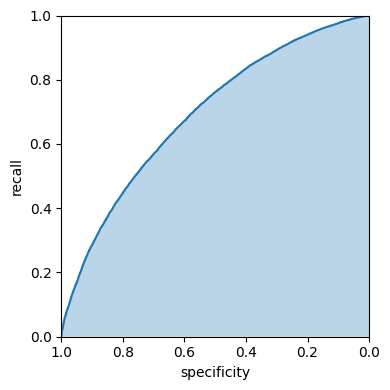

In [1]:
ax = roc_df.plot(x="specificity", y="recall", figsize=(4, 4), legend=False)
ax.set_ylim(0, 1)
ax.set_xlim(1, 0)
ax.set_xlabel("specificity")
ax.set_ylabel("recall")
ax.fill_between(roc_df.specificity, 0, roc_df.recall, alpha=0.3)

plt.tight_layout()
plt.show()

## SMOTE

In [1]:
predictors = ["payment_inc_ratio", "purpose_", "home_", "emp_len_",
              "dti", "revol_bal", "revol_util"]
outcome = "outcome"
X = pd.get_dummies(full_train_set[predictors], prefix="", prefix_sep="",
                   drop_first=True, dtype=int)
y = full_train_set[outcome]

X_resampled, y_resampled = SMOTE().fit_resample(X, y)
print("percentage of loans in default (SMOTE resampled): ",
      f"{100 * np.mean(y_resampled == 'default'):.2f}")

full_model = LogisticRegression(C=np.inf, max_iter=10_000)
full_model.fit(X_resampled, y_resampled)
print("percentage of loans predicted to default (SMOTE): ",
      f"{100 * np.mean(full_model.predict(X) == 'default'):.2f}")

X_resampled, y_resampled = ADASYN().fit_resample(X, y)
print("percentage of loans in default (ADASYN resampled): ",
      f"{100 * np.mean(y_resampled == 'default'):.2f}")

full_model = LogisticRegression(C=np.inf, max_iter=10_000)
full_model.fit(X_resampled, y_resampled)
print("percentage of loans predicted to default (ADASYN): ",
      f"{100 * np.mean(full_model.predict(X) == 'default'):.2f}")

percentage of loans in default (SMOTE resampled):  50.00


/Users/petergedeck/cdd/practical-statistics-for-data-scientists-code-3e/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


percentage of loans predicted to default (SMOTE):  29.51


percentage of loans in default (ADASYN resampled):  48.56


/Users/petergedeck/cdd/practical-statistics-for-data-scientists-code-3e/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


percentage of loans predicted to default (ADASYN):  27.37


## Figure 5-8. Comparison of the classification rules for four different methods

In [1]:
predictors = ["borrower_score", "payment_inc_ratio"]
outcome = "outcome"
X = loan3000[predictors]
y = loan3000[outcome]

loan_tree = DecisionTreeClassifier(random_state=1, criterion="entropy",
                                   min_impurity_decrease=0.003)
loan_tree.fit(X, y)

loan_lda = LinearDiscriminantAnalysis()
loan_lda.fit(X, y)

logit_reg = LogisticRegression(penalty="l2", solver="liblinear")
logit_reg.fit(X, y)


## model
gam = pygam.LinearGAM(pygam.s(0) + pygam.s(1))
print(gam.gridsearch(X.values, [1 if yi == "default" else 0 for yi in y]))

/Users/petergedeck/cdd/practical-statistics-for-data-scientists-code-3e/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--

 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00

 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00

LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, terms=s(0) + s(1) + intercept, 
   tol=0.0001, verbose=False)


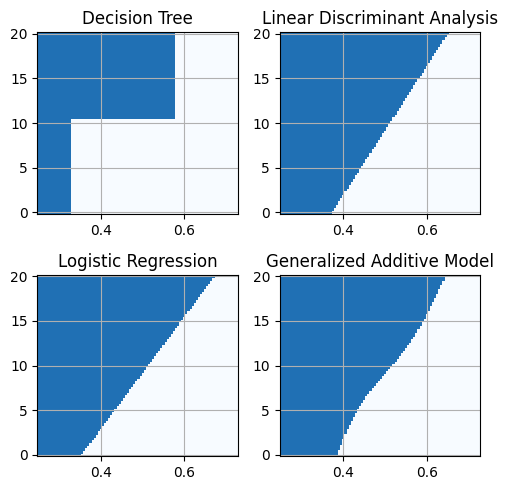

In [1]:
models = {
    "Decision Tree": loan_tree,
    "Linear Discriminant Analysis": loan_lda,
    "Logistic Regression": logit_reg,
    "Generalized Additive Model": gam,
}

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5, 5))

xvalues = np.arange(0.25, 0.73, 0.005)
yvalues = np.arange(-0.1, 20.1, 0.1)
xx, yy = np.meshgrid(xvalues, yvalues)
X = pd.DataFrame({
    "borrower_score": xx.ravel(),
    "payment_inc_ratio": yy.ravel(),
})

boundary = {}

for n, (title, model) in enumerate(models.items()):
    ax = axes[n // 2, n % 2]
    predict = model.predict(X)
    if "Generalized" in title:
        Z = np.array([1 if z > 0.5 else 0 for z in predict])
    else:
        Z = np.array([1 if z == "default" else 0 for z in predict])
    Z = Z.reshape(xx.shape)
    boundary[title] = yvalues[np.argmax(Z > 0, axis=0)]
    boundary[title][Z[-1, :] == 0] = yvalues[-1]

    c = ax.pcolormesh(xx, yy, Z, cmap="Blues", vmin=0.1, vmax=1.3, shading="auto")
    ax.set_title(title)
    ax.grid(visible=True)

plt.tight_layout()
plt.show()

# Naive Bayes with numerical features

# print(f"MixedNB Library Accuracy: {accuracy_mixed:.2f}")